# Pandas數據分析

今天介紹資料分析近來很紅的 pandas 套件, 作者是 Wes McKinney。Python 會成為一個數據分析的熱門語言, 和 pandas 的出現也有相當的關係。

但是 pandas 雖然功能強, 但有些地方沒那麼直覺, 有時會讓大家以為是個深奧的套件。其實你大約可以把 pandas 想成「Python 的 Excel」, 但是功能更強、更有彈性、也有更多的可能性。

下面介紹個基本上就是把 pandas 當 Excel 學的影片, 相信大家會覺得很親切。<br>
https://youtu.be/9d5-Ti6onew

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1 開始使用 `pandas`

首先我們來讀入一個 CSV 檔, 這裡有個「假的」學測成績, 叫 `grades.csv` 我們來練習一下。

In [58]:
df = pd.read_csv("data/grades.csv") #Data Frame

用 `df` 是標準的叫法 (雖然這名稱我們隨便取也可以), 意思是 Data Frame, 這是 `pandas` 兩大資料結構之一。我們可以把 Data Frame 想成一張表格 (雖然其實可以是很多張表格)。

我們來看看我們 `df` 的前五筆資料。

In [38]:
df.head() #前五筆資料

,姓名,國文,英文,數學,自然,社會
0,劉俊安,9,10,15,10,13
1,胡玉華,10,10,10,8,9
2,黃淑婷,13,15,8,11,14
3,陳上紫,10,10,8,9,14
4,崔靜成,13,12,14,12,13


如果你曾經手動讀入 CSV 檔, 就知道這省了多少事 (雖然我個人還挺喜歡純手動帶進 CSV)。

#### Excel 檔也可以快速讀入

不只 CSV 檔, 很多資料檔案, 像 Excel 檔都很容易在 `pandas` 完成。使用法是這樣:

    df2 = pd.read_excel('filename.xls', 'sheetname')
    
其中 sheetname 那裡要放工作表的名稱, 如果是中文的最好改成英文。

## 2 Pandas 基本資料結構

Pandas 有兩個基本資料結構:

* <b style="color:red;">DataFrame</b>: 可以想成一個表格。
* <b style="color:red;">Series</b>: 表格的某一列、某一行, 基本上就是我們以前的 list 或 array

一個 DataFrame, 我們有 `index` (列的名稱), `columns` (行的名稱)。

#### DataFrame

![DataFrame 的結構](images/indexcol.png)

#### Series

剛剛說 series 大概就是一個 list, 一個 array。其實更精準的說, 其實是一個有 "index" 的 array。

DataFrame 的每一行或每一列其實也都是一個 series。我們來看個例子, 例如所有同學的國文成績, 就是一個 series。

In [39]:
df["國文"] #例如所有同學的國文成績

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

在 Python 3 中, 我們終於可以和英文同步, 用這種很炫的方式叫出所有國文成績。

In [40]:
df.國文

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

#### 資料畫出來

要畫個圖很容易。

<Axes: >

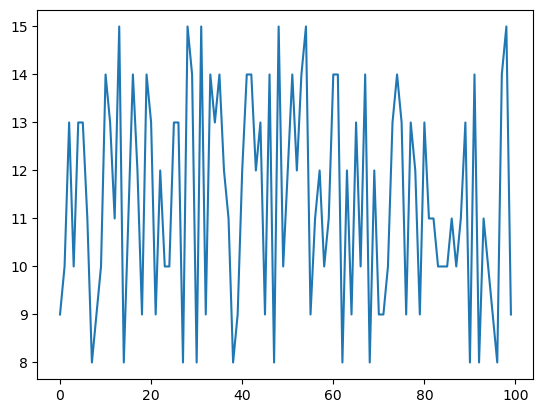

In [12]:
df.國文.plot()

當然, 在這個例子中, 其實畫 histogram 圖更有意義一點。

<Axes: >

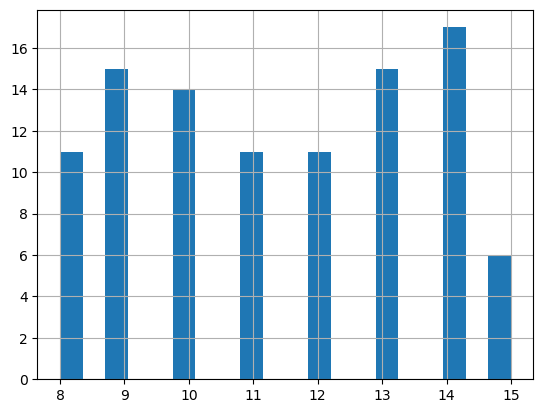

In [14]:
df.國文.hist(bins=20)

## 3 一些基本的資料分析

算平均。

In [41]:
df.國文.mean()

np.float64(11.39)

算標準差。

In [42]:
df.國文.std()

2.1968526614594834

不如就該算的都幫我們算算...

In [43]:
df.describe()

,國文,英文,數學,自然,社會
count,100.000000,100.000000,100.000000,100.00000,100.00000
mean,11.390000,11.380000,11.570000,11.03000,11.83000
std,2.196853,2.273164,2.310516,2.21772,2.48655
min,8.000000,8.000000,8.000000,8.00000,8.00000
25%,9.000000,9.000000,10.000000,9.00000,9.00000
50%,11.000000,11.000000,11.000000,11.00000,12.00000
75%,13.000000,13.000000,14.000000,13.00000,14.00000
max,15.000000,15.000000,15.000000,15.00000,15.00000


有時我們很愛看的相關係數矩陣。

In [44]:
df.dtypes #姓名 是 object（文字/字串）#科目 都是 int64（整數數字）


姓名    object
國文     int64
英文     int64
數學     int64
自然     int64
社會     int64
dtype: object

In [49]:


df.corr(numeric_only=True) #自動忽略文字欄位,不然error...

,國文,英文,數學,自然,社會
國文,1.000000,0.160158,-0.310899,-0.110236,-0.028421
英文,0.160158,1.000000,0.025656,0.113929,-0.063512
數學,-0.310899,0.025656,1.000000,0.014371,0.041651
自然,-0.110236,0.113929,0.014371,1.000000,-0.156594
社會,-0.028421,-0.063512,0.041651,-0.156594,1.000000


只算兩科間的相關係數當然也可以。

In [50]:
df.國文.corr(df.自然)

np.float64(-0.11023608610722796)

## 4 增加一行

### 【技巧】

我們增加一行, 加入總級分。

In [94]:

df['總級分'] =df.sum(axis = 1, numeric_only=True) #自動忽略文字
df.head()

,姓名,國文,英文,數學,自然,社會,總級分,加權
0,劉俊安,9,10,15,10,13,375,49
1,胡玉華,10,10,10,8,9,308,40
2,黃淑婷,13,15,8,11,14,376,44
3,陳上紫,10,10,8,9,14,312,36
4,崔靜成,13,12,14,12,13,415,53


### 【技巧】

有計算的當然也可以的。

In [61]:
df["加權"] = df.國文 + df.英文 + df.數學*2

In [62]:
df.head()

,姓名,國文,英文,數學,自然,社會,總級分,加權
0,劉俊安,9,10,15,10,13,57,49
1,胡玉華,10,10,10,8,9,47,40
2,黃淑婷,13,15,8,11,14,61,44
3,陳上紫,10,10,8,9,14,51,36
4,崔靜成,13,12,14,12,13,64,53


## 5 排序和 index 重設

### 【重點】排序的方法

我們依總級分來排序。

In [96]:
df.sort_values(by= '總級分',ascending = False).head(10)

,姓名,國文,英文,數學,自然,社會,總級分,加權
57,胡淳茜,12,15,14,13,11,425,55
25,蔡亦瑄,13,13,14,13,12,422,54
83,李士賢,10,14,15,13,13,422,54
36,詹威德,12,13,15,10,14,421,55
80,施雅鈴,13,15,12,13,13,420,52
48,陳怡婷,15,14,12,9,15,419,53
37,曾怡君,11,12,15,13,14,419,53
4,崔靜成,13,12,14,12,13,415,53
87,趙偉希,10,13,14,13,15,413,51
73,吳志遠,13,15,15,8,8,410,58


### 【重點】排序的方法

加權分最高, 同分才看總級分

In [68]:
df.sort_values(by=['加權','總級分'],ascending = False).head(10)

,姓名,國文,英文,數學,自然,社會,總級分,加權
73,吳志遠,13,15,15,8,8,59,58
57,胡淳茜,12,15,14,13,11,65,55
36,詹威德,12,13,15,10,14,64,55
25,蔡亦瑄,13,13,14,13,12,65,54
83,李士賢,10,14,15,13,13,65,54
44,童心怡,13,13,14,8,13,61,54
37,曾怡君,11,12,15,13,14,65,53
48,陳怡婷,15,14,12,9,15,65,53
4,崔靜成,13,12,14,12,13,64,53
67,林哲法,14,9,15,10,14,62,53


### 【重點】重設 index

In [89]:
df2 = df.sort_values(by=['加權','總級分'],ascending = False)

df2.index = range(1,101)
df2.head()

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,293,58
2,胡淳茜,12,15,14,13,11,305,55
3,詹威德,12,13,15,10,14,302,55
4,蔡亦瑄,13,13,14,13,12,303,54
5,李士賢,10,14,15,13,13,303,54


## 6 篩出我們要的資料

基本上和 NumPy 的 array 篩法很像。

### 【重點】

找出數學滿級分同學。

In [72]:
df2[df2.數學==15]

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58
3,詹威德,12,13,15,10,14,64,55
5,李士賢,10,14,15,13,13,65,54
7,曾怡君,11,12,15,13,14,65,53
10,林哲法,14,9,15,10,14,62,53
13,陳竹伯,10,12,15,10,14,61,52
15,葉儀依,9,13,15,8,14,59,52
18,周育霖,9,12,15,13,12,61,51
21,張雅彬,10,11,15,12,8,56,51
22,芮秋辛,11,10,15,10,8,54,51


### 【重點】

找出數學和英文都滿級分的同學。要注意 `and` 要用 `&`, `or` 要用 `|`。每個條件一定要加弧號。

In [79]:
df2[(df2.數學==15) & (df2.英文==15)]

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58


## 7 刪除一行或一列

### 【重點】刪掉一行

我們來刪掉總級分的那行。

In [90]:
df3 = df2.drop(columns=["總級分"])
#df3 = df2.drop("總級分", axis=1)
df3

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
5,李士賢,10,14,15,13,13,54
...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36
97,胡凱琳,10,8,9,9,15,36
98,林建亨,9,11,8,8,11,36
99,梁慧君,9,8,8,8,12,33


In [98]:
df2.drop("總級分", axis=1, inplace=True, errors='ignore')#程式碼重複執行時就算欄位不在也不要報錯
df2.head()

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
5,李士賢,10,14,15,13,13,54


### 【重點】改變原有的 DataFrame

我們會發現 `pandas` 很多動作都沒有更改原有的 DataFrame, 真的要改要加入

    inplace=True

In [ ]:
df2.drop("總級分", axis=1, inplace=True)
df2.head()

### 【重點】刪掉一列

刪掉列就是指定要刪去的 index。

In [100]:
df2.drop(5).head()


,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
6,童心怡,13,13,14,8,13,54


In [102]:
df2[df2.姓名=="童心怡"]

,姓名,國文,英文,數學,自然,社會,加權
6,童心怡,13,13,14,8,13,54


In [105]:
df2.drop(df2[df2.姓名=="童心怡"].index).head()

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
5,李士賢,10,14,15,13,13,54


### 【重點】刪掉一列

通常刪掉符合條件的比較合理 (注意是找到要刪掉的部份, 再找出相對的 index)。

In [106]:
df2.drop(df2[df2.姓名=="李士賢"].index)

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
6,童心怡,13,13,14,8,13,54
...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36
97,胡凱琳,10,8,9,9,15,36
98,林建亨,9,11,8,8,11,36
99,梁慧君,9,8,8,8,12,33


## 8 真實股價資料

有個從 `Pandas` 獨立出來的套件叫 `pandas-datareader`, 幾經波折, 先是 Yahoo! 的財務資料不能用, 後來又是 Google 的資料不能用, 不過至少現在看來 Yahoo! 還可以使用。

安裝 `pandas-datareader` 就標準 `conda` 安裝:

    conda install pandas-datareader
    
如果裝過, 但很久沒更新就用:

    conda update pandas-datareader

### 【例子】 分析 Apple 股價

In [127]:
#抓取台美股等 Yahoo Finance 資料，業界和教學上都全面改用 yfinance 套件
import yfinance as yf

df = yf.download('AAPL', period='max') #抓取全部歷史資料
#df = pd.read_csv('data/aapl.csv', index_col="Date")

[*********************100%***********************]  1 of 1 completed


In [119]:
# 為防止網路有問題, 我們把這個檔案以 aapl.csv 存起來, 可以這樣讀入。
# df = pd.read_csv('data/aapl.csv', index_col="Date")

In [128]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1980-12-12,0.098122,0.098549,0.098122,0.098122,469033600
1980-12-15,0.093003,0.093430,0.093003,0.093430,175884800
1980-12-16,0.086177,0.086604,0.086177,0.086604,105728000
1980-12-17,0.088310,0.088737,0.088310,0.088310,86441600
1980-12-18,0.090870,0.091297,0.090870,0.090870,73449600


#### 只要最後 300 個交易日!

In [130]:
df_last_300 = df [-300 :]
df_last_300


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-06-16,197.465652,197.734358,195.614598,196.351044,43020700
2025-06-17,194.699020,197.435794,194.271096,196.251515,38856200
2025-06-18,195.634476,196.619719,194.131744,194.997555,45394700
2025-06-20,200.033218,200.729848,195.913132,197.286499,96813500
2025-06-23,200.530807,201.326963,198.003031,200.660187,55814300
...,...,...,...,...,...
2026-08-19,316.829987,319.279999,309.600006,310.140015,50505600
2026-08-20,311.299988,320.279999,310.649994,317.459991,40959200


#### 20 日的移動平均

<Axes: xlabel='Date'>

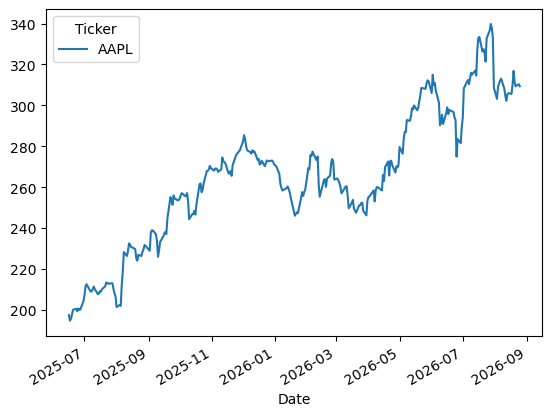

In [138]:
df_last_300 .Close.plot()


<Axes: xlabel='Date'>

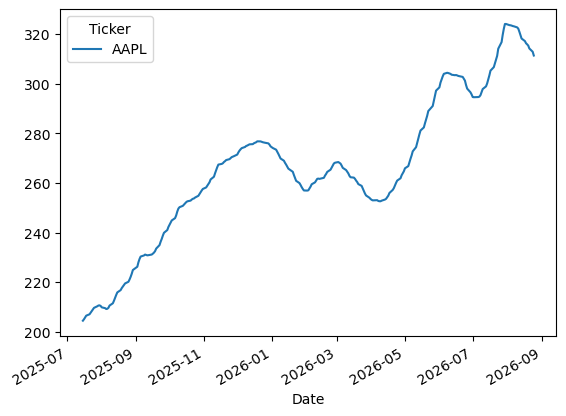

In [141]:

df_last_300.Close.rolling(20).mean().plot()

#### 20 日和 60 日的移動平均

<Axes: xlabel='Date'>

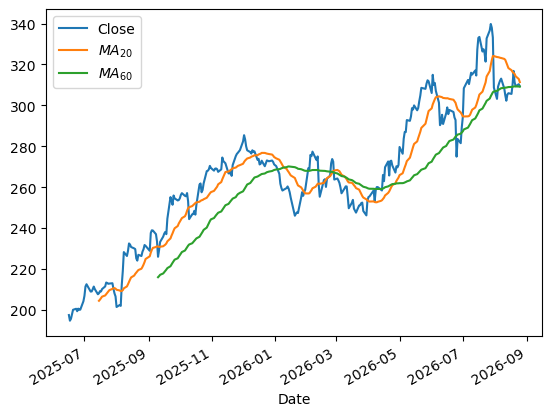

In [148]:
'''ax = df_last_300.Close.plot(legend=True, label="Close")
 # ax=ax 疊在同一個圖表裡

#df_last_300.Close.rolling(20).mean().rename("$MA_{20}$").plot(legend=True, label="$MA_{20}$", ax=ax)
#df_last_300.Close.rolling(60).mean().rename("$MA_{60}$").plot(legend=True, label="$MA_{60}$", ax=ax)
'''

#.squeeze() 把 Close 轉成純 Series
#建立一個全新的 Pandas 資料框
df_plot = pd.DataFrame({
    'Close': df_last_300['Close'].squeeze(), #第一個欄位'Close'
    '$MA_{20}$': df_last_300['Close'].squeeze().rolling(20).mean(),
    '$MA_{60}$': df_last_300['Close'].squeeze().rolling(60).mean()
})
df_plot.plot(legend=True)

#### 準備做預測

我們用個非常天真的模型...

![天真股票模型](images/naive.png)

網路上說這是線性的 (可能嗎)!


In [150]:
close = df_last_300.Close.values
len(close)

300

In [152]:
x = close[:-1] #不含終止值
len(x)

299

In [153]:
y =close[1:] #不含起始值
len(y)

299

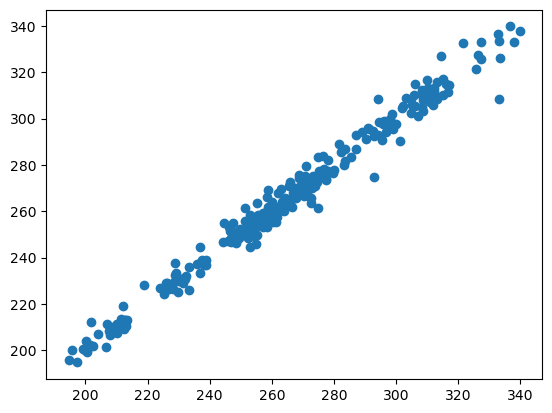

In [154]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

哦, 真的有點像線性的, 我們之後用線性迴歸試試看。

## 9 手工打造一個 DataFrame*

有時我們用手工打造一個簡單的 DataFrame, 可以更理解整個結構。其實很容易, 一個 DataFrame 基本上就包含兩個主要部份:

* 資料本身: 通常一個二維陣列 (矩陣)
* 行、列的名稱

我們來個簡單的小例子。

In [156]:

mydata = np.random.randn(4,3)

In [157]:
mydata

array([[-0.67792388,  0.39140243, -0.83948005],
       [ 0.26793084, -1.64401032,  0.13698548],
       [-0.34378362,  1.04041532,  0.23376494],
       [ 1.39007899,  0.80469753,  0.87181288]])

把行列的名字放進去, 就成一個 DataFrame。我們列的部份先讓 Python 自己產生。

In [160]:
df4 = pd.DataFrame(mydata, columns=list("ABC"))

In [161]:
df4

,A,B,C
0,-0.677924,0.391402,-0.839480
1,0.267931,-1.644010,0.136985
2,-0.343784,1.040415,0.233765
3,1.390079,0.804698,0.871813


#### 兩個表格上下貼起來

我們再來生一個 DataFrame, 再「貼」起來。

In [162]:
df3 = pd.DataFrame(np.random.randn(3,3), columns=list("ABC"))

In [163]:
df3

,A,B,C
0,-0.871905,1.408710,-0.287424
1,0.903614,-0.841403,-0.115455
2,0.183129,0.770675,0.372423


In [164]:
df5 = pd.concat([df4,df3],axis=0)

In [165]:
df5

,A,B,C
0,-0.677924,0.391402,-0.839480
1,0.267931,-1.644010,0.136985
2,-0.343784,1.040415,0.233765
3,1.390079,0.804698,0.871813
0,-0.871905,1.408710,-0.287424
1,0.903614,-0.841403,-0.115455
2,0.183129,0.770675,0.372423


前面我們弄得亂七八糟的 index 重設一下。

In [166]:
df5.index = range(len(df5))

In [167]:
df5

,A,B,C
0,-0.677924,0.391402,-0.839480
1,0.267931,-1.644010,0.136985
2,-0.343784,1.040415,0.233765
3,1.390079,0.804698,0.871813
4,-0.871905,1.408710,-0.287424
5,0.903614,-0.841403,-0.115455
6,0.183129,0.770675,0.372423


#### 横向的貼

In [168]:
df5 = pd.concat([df4,df3],axis=1)

等等, 這大小好像不太對也可以嗎? 答案是可以的!

In [169]:
df5

,A,B,C,A,B,C
0,-0.677924,0.391402,-0.839480,-0.871905,1.408710,-0.287424
1,0.267931,-1.644010,0.136985,0.903614,-0.841403,-0.115455
2,-0.343784,1.040415,0.233765,0.183129,0.770675,0.372423
3,1.390079,0.804698,0.871813,NaN,NaN,NaN


#### 大一點的例子

我們來做前面「假的」學測資料。首先要有「假的」同學名單, 如果有興趣產生很多名字, 可以用這個服務。

[中文姓名產生器](http://www.richyli.com/name/index.asp)

In [172]:
df_names = pd.read_csv('data/names.csv',names=['姓名'])

In [174]:
df_names

,姓名
0,羅雅慧
1,王紹尹
2,黃季坤
3,許正書
4,張鈞蓮
...,...
95,陳君生
96,曾桂甫
97,林欣怡
98,林佳霖


In [176]:
#隨機生成
df_grades = pd.DataFrame(np.random.randint(6,16,(100,5)),
                        columns=['國文','英文','數學','社會','自然'])
#隨機數字範圍 6 到 15
#產生 100 列（100位學生）、5 欄（5個科目）

In [178]:
df_grades.to_csv('data/grade_random.csv')

In [179]:
df_grades

,國文,英文,數學,社會,自然
0,15,10,8,13,7
1,11,12,12,13,6
2,15,9,7,15,9
3,12,14,6,8,9
4,10,8,10,8,9
...,...,...,...,...,...
95,7,8,11,7,8
96,10,12,13,9,7
97,11,15,13,9,12
98,8,14,12,13,10


In [182]:
df_score = pd.concat([df_names,df_grades],axis=1) #axis=1左右並排

In [183]:
df_score

,姓名,國文,英文,數學,社會,自然
0,羅雅慧,15,10,8,13,7
1,王紹尹,11,12,12,13,6
2,黃季坤,15,9,7,15,9
3,許正書,12,14,6,8,9
4,張鈞蓮,10,8,10,8,9
...,...,...,...,...,...,...
95,陳君生,7,8,11,7,8
96,曾桂甫,10,12,13,9,7
97,林欣怡,11,15,13,9,12
98,林佳霖,8,14,12,13,10
